In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [4]:
df = pd.read_csv("/content/other-American_B01362.csv")

In [5]:
df.head(10)

,DATE,TIME,PICK UP ADDRESS
0,07-01-2014,12:00:00 AM,"874 E 139th St Mott Haven, BX"
1,07-01-2014,12:01:00 AM,"628 E 141st St Mott Haven, BX"
2,07-01-2014,12:01:00 AM,"601 E 156th St South Bronx, BX"
3,07-01-2014,12:01:00 AM,"708 E 138th St Mott Haven, BX"
4,07-01-2014,12:02:00 AM,"700 E 140th St Mott Haven, BX"
5,07-01-2014,12:03:00 AM,"514 E 163rd St Cortlandt, BX"
6,07-01-2014,12:08:00 AM,"300 E 150th St Cortlandt, BX"
7,07-01-2014,12:10:00 AM,"370 E 153rd St South Bronx, BX"
8,07-01-2014,12:11:00 AM,"455 E 148th St South Bronx, BX"
9,07-01-2014,12:11:00 AM,"600 E 141st St Mott Haven, BX"


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91712 entries, 0 to 91711
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   DATE             91712 non-null  object
 1   TIME             91712 non-null  object
 2   PICK UP ADDRESS  91712 non-null  object
dtypes: object(3)
memory usage: 2.1+ MB


In [7]:
LE = LabelEncoder()
df['PICK UP ADDRESS'] = LE.fit_transform(df['PICK UP ADDRESS'])
df['DATE'] = LE.fit_transform(df['DATE'])
df['TIME'] = LE.fit_transform(df['TIME'])

In [8]:
SS = StandardScaler()
df['TIME'] = SS.fit_transform(df[['TIME']])

In [9]:
df.head(10)

,DATE,TIME,PICK UP ADDRESS
0,0,-1.130267,7737
1,0,-1.125756,6219
2,0,-1.125756,6008
3,0,-1.125756,6737
4,0,-1.121244,6680
5,0,-1.116733,5382
6,0,-1.094177,3430
7,0,-1.085154,4147
8,0,-1.080643,4922
9,0,-1.080643,5987


In [10]:
df.describe()

,DATE,TIME,PICK UP ADDRESS
count,91712.000000,9.171200e+04,91712.000000
mean,45.269005,-4.369615e-17,5100.699538
std,26.694378,1.000005e+00,2022.195463
min,0.000000,-1.671615e+00,0.000000
25%,22.000000,-9.317723e-01,3856.000000
50%,45.000000,4.942207e-02,5239.000000
75%,69.000000,9.358804e-01,6499.000000
max,91.000000,1.574221e+00,10607.000000


In [11]:
df.isnull().sum()

,0
DATE,0
TIME,0
PICK UP ADDRESS,0


In [12]:
X_question = df.iloc[:,:]
q_mean = X_question.mean(axis = 0)
total_mean = q_mean.mean()

In [13]:
q_mean

,0
DATE,4.526901e+01
TIME,-4.369615e-17
PICK UP ADDRESS,5.100700e+03


In [14]:
total_mean

np.float64(1715.3228476099093)

In [15]:
q_mean = q_mean.to_frame('mean')
q_mean.reset_index(level=0,inplace=True)

In [16]:
q_mean

,index,mean
0,DATE,4.526901e+01
1,TIME,-4.369615e-17
2,PICK UP ADDRESS,5.100700e+03


<Axes: xlabel='index', ylabel='mean'>

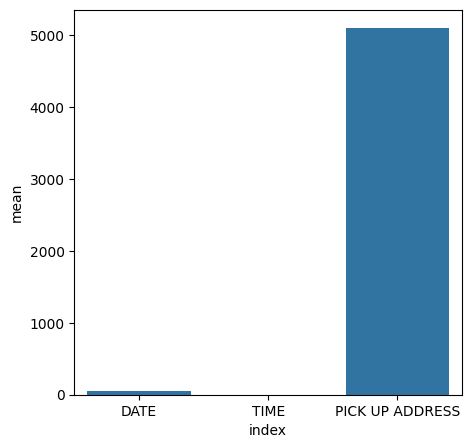

In [18]:
plt.figure(figsize=(5,5))
sns.barplot(x = 'index',y = 'mean',data = q_mean)

<Axes: >

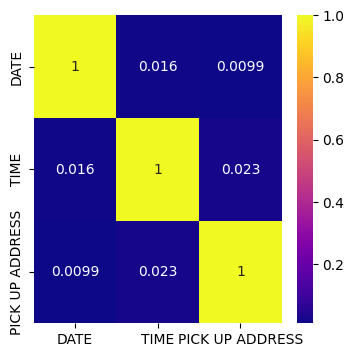

In [22]:
corr = df.corr()
plt.figure(figsize=(4,4))
sns.heatmap(corr,annot=True,cmap='plasma')

In [23]:
X = df.iloc[:,:]
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(X)

In [24]:
pca

PCA(n_components=2, random_state=42)

In [25]:
X_pca

array([[ 2636.29449191,   -45.61529557],
       [ 1118.29450511,   -45.41627702],
       [  907.29450693,   -45.38861408],
       ...,
       [ 1101.30643461,    45.58590964],
       [-1137.69354584,    45.87945952],
       [ 2499.30642287,    45.40264494]])

In [26]:
pca.explained_variance_ratio_.cumsum()[0]

np.float64(0.9998255449686095)

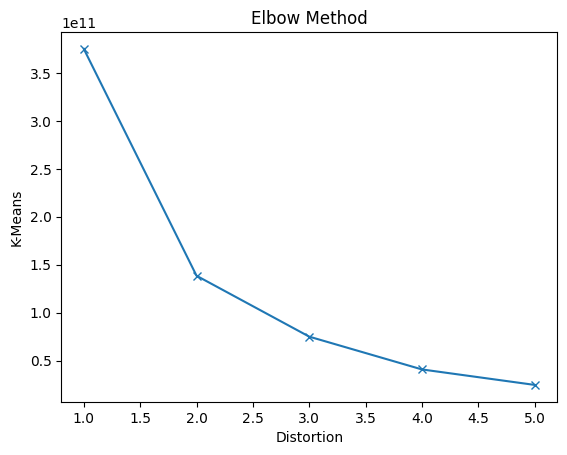

In [27]:
distortion = []
for i in range(1,6):
  km = KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
  km.fit(X_pca)
  distortion.append(km.inertia_)
plt.plot(range(1,6),distortion,marker='x')
plt.xlabel("Distortion")
plt.ylabel("K-Means")
plt.title("Elbow Method")
plt.show()

In [28]:
model = KMeans(n_clusters=2,init='k-means++',random_state=42,n_init=10)
model.fit(X_pca)
y = model.predict(X_pca)

In [30]:
model

KMeans(n_clusters=2, n_init=10, random_state=42)

In [29]:
y

array([1, 1, 1, ..., 1, 0, 1], dtype=int32)

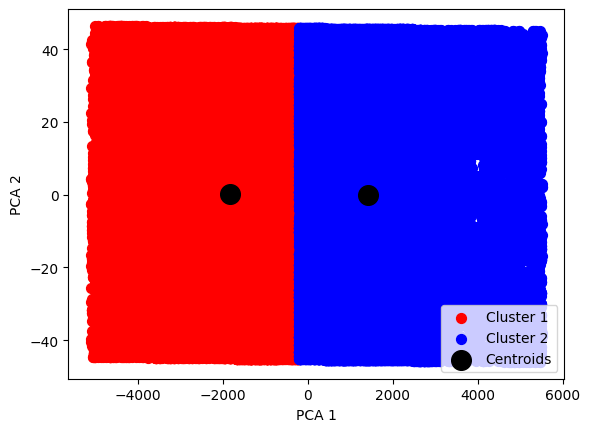

In [31]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red',label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='blue',label='Cluster 2')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=200,c='black',label='Centroids')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()